In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
url = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/df_pre_enc.csv'
df = pd.read_csv(url)

In [6]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

Considerando que el análisis univariado de variables categóricas se hizo en parte al momento de hacer el encoding en una notebook anterior, en este caso veremos solo una pequeña parte de eso, y pasaremos directo al análisis de variables numéricas, que en la mayoría de los casos son variables que fueron creadas por mí.

## Análisis Categóricas

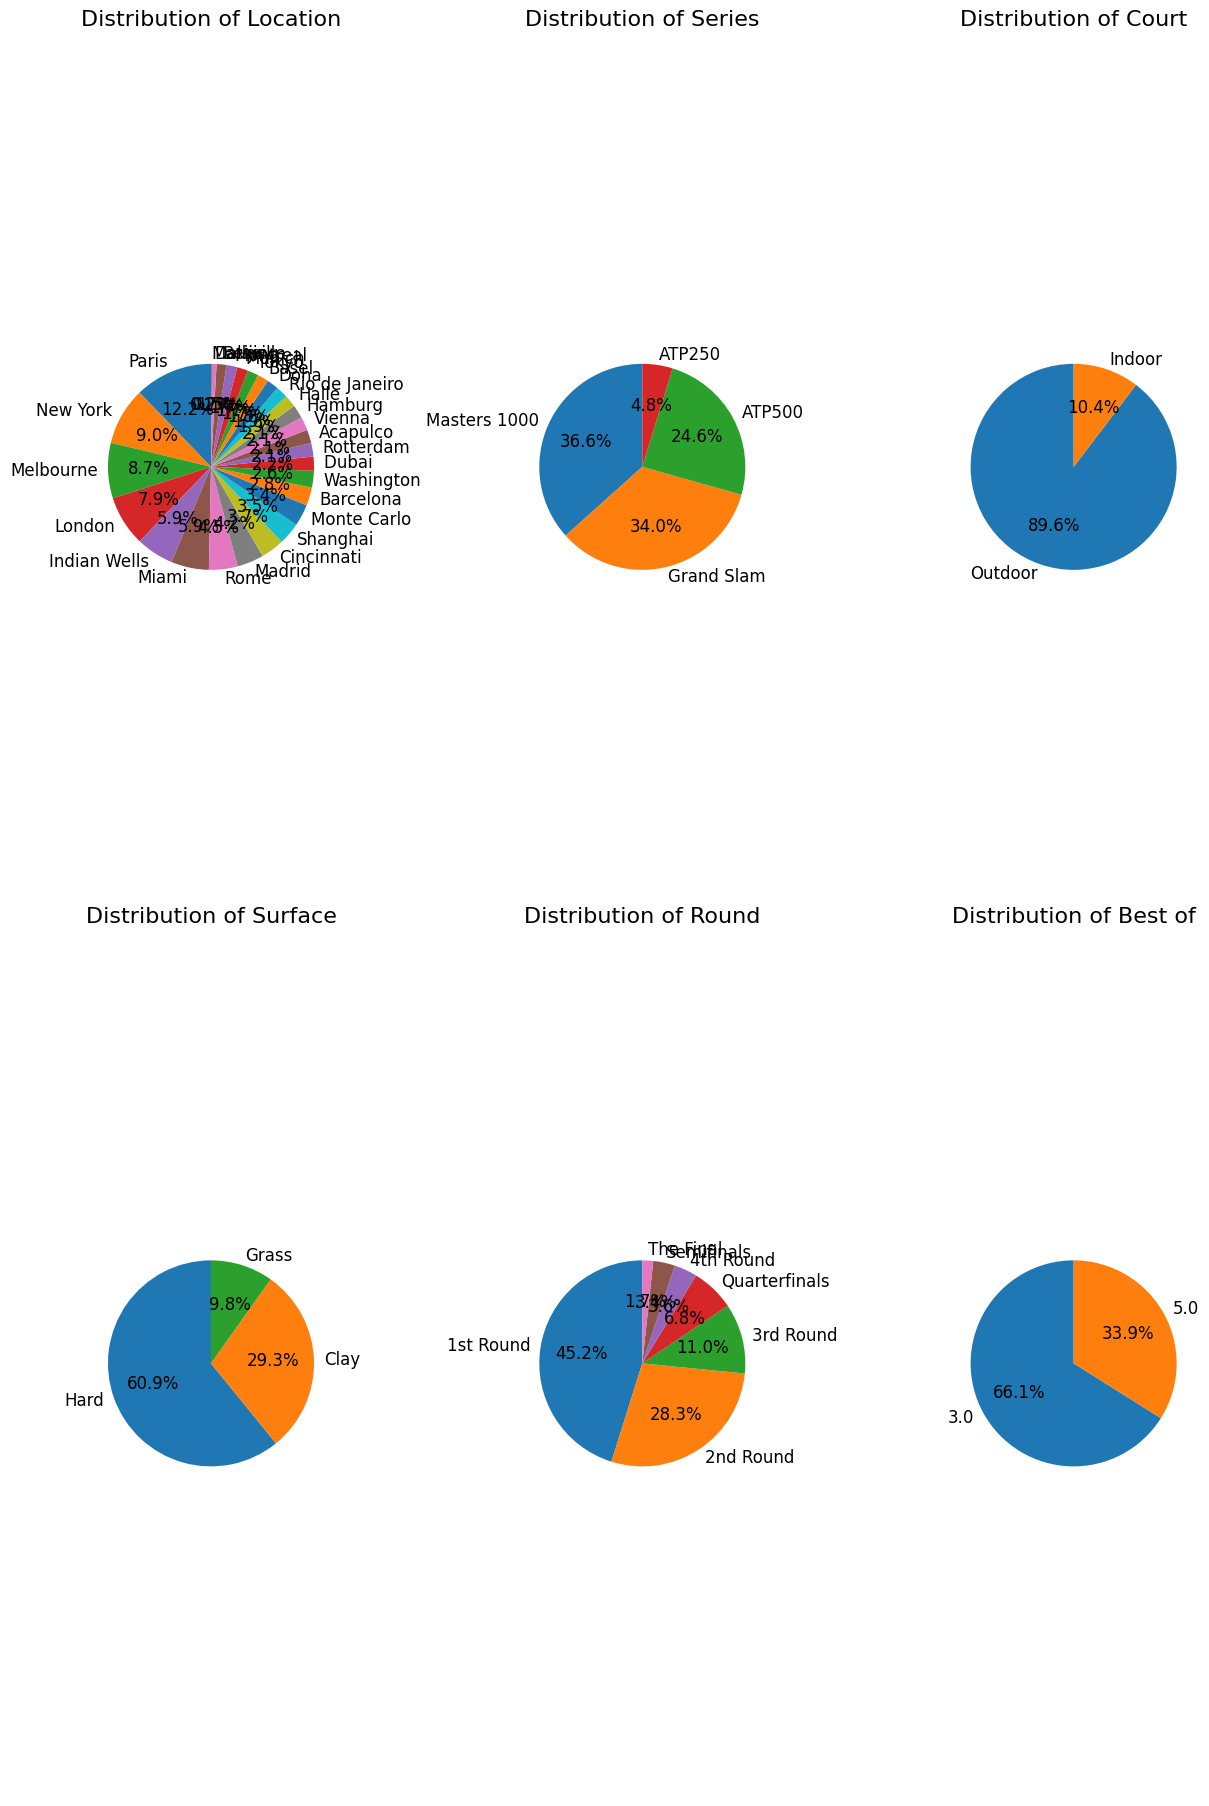

In [22]:
vars_cat = ['Location', 'Series', 'Court', 'Surface', 'Round', 'Best of']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,18))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
  axes[i].pie(df[var].value_counts(),
              labels=df[var].value_counts().index,
              autopct='%1.1f%%',
              startangle=90,
              textprops={'fontsize': 12})
  axes[i].set_title(f'Distribution of {var}', fontsize=16)
  axes[i].axis('equal')

# Hide any unused subplots
for j in range(len(vars_cat), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=0.5) # Reduced padding to bring titles closer
plt.show()

*Insights*:
- Las ciudades tiene más o menos la misma cantidad de partidos. Seguramente dependiendo de la cantidad de partidos del torneo hayan acumulado más o menos partidos a lo largo de los años que comprende el dataset
- Tenemos partidos de Grand Slam, Masters 1000 y ATP500 en proporciones similares. Pero de ATP250 no extrajimos datos, ¿cómo es eso posible?
- Casi siempre se juega afuera: el 90% de los partidos
- El pasto como superficie es inusual, algo que tiene mucho sentido si lo analizamos desde un punto de vista tenístico, y la superficie dura abunda como predominante
- Las primeras dos rondas son las que tienen más partidos: lógico, a medida que avanzan las rondas quedan menos participantes y por ende hay menos partidos
- La mayoría de partidos son a 3 sets. Esto tiene correlación intrínseca con el nivel del torneo

Observamos esta curiosidad. Cuando hicimos el scraping, scrapeamos a torneos ATP 500 o superior. Pero como extrajimos los últimos 10 años ocurrió que algunos torneos cambiaron de status (de ATP 250 subieron a ser ATP 500) hace menos tiempo entonces también se registran partidos de ese nivel. Los dejamos en la base.

In [21]:
df['Series'].value_counts()

,count
Series,
Masters 1000,5884
Grand Slam,5459
ATP500,3954
ATP250,764


In [20]:
# Ciudades que registran partidos de ATP250
df[df['Series'] == 'ATP250']['Location'].value_counts()

,count
Location,
Doha,263
Munich,243
Hamburg,119
Dallas,81
Vienna,31
Marseille,27


Comparamos la cantidad de partidos por ciudad

In [16]:
pd.DataFrame(df['Location'].value_counts()).T

Location,Paris,New York,Melbourne,London,Indian Wells,Miami,Rome,Madrid,Cincinnati,Shanghai,Monte Carlo,Barcelona,Washington,Dubai,Rotterdam,Acapulco,Vienna,Hamburg,Halle,Rio de Janeiro,Doha,Basel,Tokyo,Munich,Montreal,Beijing,Dallas,Marseille
count,1960,1451,1397,1270,950,950,724,670,590,560,548,454,423,355,341,341,341,336,310,304,294,279,279,274,273,248,112,27
